In [ ]:
# === Google Colab 自動環境セットアップ ===
# ※ローカル環境では無視され、Colab環境でのみ自動でモジュールをインストールします
import sys, os

if 'google.colab' in sys.modules:
    REPO_NAME = "study-deep-learning"
    REPO_URL = f"https://github.com/miyayudai/{REPO_NAME}.git"
    TARGET_DIR = f"/content/{REPO_NAME}"
    CH_DIR = f"{TARGET_DIR}/12"

    # 1. リポジトリのダウンロード (未ダウンロード時のみ)
    if not os.path.exists(TARGET_DIR):
        print("📦 リポジトリをダウンロード中...")
        res = os.system(f"git clone {REPO_URL} {TARGET_DIR} 2>&1")
        
        # Private リポジトリ等で認証が必要な場合の自動救済
        if res != 0 or not os.path.exists(TARGET_DIR):
            token = None
            try:
                from google.colab import userdata
                token = userdata.get('GITHUB_TOKEN')
            except Exception:
                pass
            
            if not token:
                import getpass
                print("🔒 リポジトリが非公開(Private)の場合、GitHub Personal Access Token (PAT) が必要です。")
                print("※公開(Public)リポジトリの場合はそのまま Enter を押してください。")
                token = getpass.getpass("GitHub Token (空欄可): ").strip()
            
            if token:
                auth_url = f"https://{token}@github.com/miyayudai/{REPO_NAME}.git"
                os.system(f"git clone {auth_url} {TARGET_DIR}")

    # 2. 依存パッケージとローカルモジュールのインストール
    print("⚙️ 環境セットアップ中...")
    if os.path.exists(TARGET_DIR):
        if TARGET_DIR not in sys.path:
            sys.path.insert(0, TARGET_DIR)
        req_path = os.path.join(TARGET_DIR, "requirements.txt")
        if os.path.exists(req_path):
            get_ipython().system(f"pip install -q -r {req_path}")
            get_ipython().system(f"pip install -q -e {TARGET_DIR}")
        if os.path.exists(CH_DIR):
            get_ipython().run_line_magic("cd", CH_DIR)
        else:
            get_ipython().run_line_magic("cd", TARGET_DIR)
        print("✅ 準備完了！このまま下のセルを実行できます。")
    else:
        print("⚠️ リポジトリのクローンがスキップされたため、必須パッケージを個別インストールします...")
        get_ipython().system("pip install -q pandas scikit-learn seaborn pillow")
        print("✅ パッケージインストール完了。")

# 第12章 トランスフォーマー (Transformers)
## 12.1 注意機構 (Attention)

本ノートブックは、Christopher M. Bishop & Hugh Bishop (2024)『深層学習：基礎と概念 (Deep Learning: Foundations and Concepts)』第12章「トランスフォーマー」第12.1節「注意機構 (Attention)」の全9小節（12.1.1 〜 12.1.9）の完全な理論解説、数学的定式化（式 12.1 〜 式 12.25）、教科書図版（Figure 12.1 〜 12.10 全10枚）の完全再現、共通モジュール実装、および数値検証を提供します。

---

### 目次
1. **環境設定と共通モジュールのインポート**
2. **注意機構の直観と動機 (Figure 12.1, 12.2)**
   - 文脈依存の意味解釈：文脈語（'river', 'swam'）による多義語（'bank'）の解釈シフト
   - 固定重みニューラルネットワークと入力依存重み（注意重み）の本質的差異
3. **12.1.1 トランスフォーマーの処理 (Transformer Processing, Figure 12.3, 式 12.1)**
   - トークン行列 $X \in \mathbb{R}^{N \times D}$ のデータ構造（$N$ 個のトークン、各行 $\mathbf{x}_n^T$、各列 $D$ 次元特徴量）
   - トランスフォーマー層の基本写像 $\widetilde{X} = \text{TransformerLayer}[X]$
4. **12.1.2 注意係数 (Attention Coefficients, 式 12.2 〜 12.4)**
   - 凸結合・1の分割制約：$a_{nm} \ge 0, \sum_{m=1}^N a_{nm} = 1$
   - 出力表現 $\mathbf{y}_n = \sum_{m=1}^N a_{nm} \mathbf{x}_m$
5. **12.1.3 自己注意 (Self-Attention, 式 12.5 〜 12.6)**
   - 情報検索のアナロジー：クエリ (Query)、キー (Key)、バリュー (Value)
   - ソフトマックス内積類似度：$a_{nm} = \frac{\exp(\mathbf{x}_n^T \mathbf{x}_m)}{\sum_{m'} \exp(\mathbf{x}_n^T \mathbf{x}_{m'})}$
   - 行列形式：$Y = \text{Softmax}(X X^T) X$
6. **12.1.4 ネットワークパラメータ (Network Parameters, Figure 12.4, 12.5, 式 12.7 〜 12.13)**
   - 単純線形写像 $X U$ の限界と対称性問題（$X U U^T X^T$ が対称）
   - 非対称な注意を可能にする独立パラメータ行列：$Q = X W_Q, K = X W_K, V = X W_V$
   - 行列積 $Q K^T$（図 12.4）と $Y = A V$（図 12.5）
7. **12.1.5 スケール化自己注意 (Scaled Self-Attention, Figure 12.6, Algorithm 12.1, 式 12.14)**
   - 次元 $D_k$ の増大に伴う内積分散の拡大とソフトマックス勾配消失の防止 ($1/\sqrt{D_k}$)
   - $\text{Attention}(Q, K, V) = \text{Softmax}\left( \frac{Q K^T}{\sqrt{D_k}} \right) V$
8. **12.1.6 マルチヘッド注意 (Multi-Head Attention, Figure 12.7, 12.8, Algorithm 12.2, 式 12.15 〜 12.19)**
   - 複数の異なる部分空間での注意関係の並列学習（$H$ 個の独立ヘッド）
   - ヘッド連結と出力線形射影：$Y = \text{Concat}[H_1, \dots, H_H] W^{(o)}$
9. **12.1.7 トランスフォーマー層 (Transformer Layers, Figure 12.9, Algorithm 12.3, 式 12.20 〜 12.23)**
   - 残差接続 (Residual Connections) と層正規化 (Layer Normalization)
   - トークン単位の非線形性：多層パーセプトロン (MLP / Feed-Forward)
   - Post-LN と Pre-LN の構造比較
10. **12.1.8 計算量 (Computational Complexity)**
    - 自己注意層 $O(N^2 D)$ vs MLP層 $O(N D^2)$ vs 全結合層 $O(N^2 D^2)$
11. **12.1.9 位置エンコーディング (Positional Encoding, Figure 12.10, 式 12.24 〜 12.25)**
    - トランスフォーマーの置換同変性 (Permutation Equivariance) と語順情報の不可欠性
    - 加算的位置ベクトル $\widetilde{\mathbf{x}}_n = \mathbf{x}_n + \mathbf{r}_n$
    - 正弦波・余弦波位置エンコーディング（波長変化、相対位置の線形回転不変性）
12. **数値検証・実験コード**
13. **まとめと次節 12.2（自然言語処理）への展開**


In [1]:
import sys
import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# リポジトリルートをパスに追加
repo_root = Path.cwd().parent if Path.cwd().name == "12" else Path.cwd()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from common.plot_utils import setup_style
from common.attention import (
    softmax,
    ScaledDotProductAttention,
    MultiHeadAttention,
    LayerNorm,
    TransformerMLP,
    TransformerLayer,
    sinusoidal_positional_encoding,
    generate_figure_12_1,
    generate_figure_12_2,
    generate_figure_12_3,
    generate_figure_12_4,
    generate_figure_12_5,
    generate_figure_12_6,
    generate_figure_12_7,
    generate_figure_12_8,
    generate_figure_12_9,
    generate_figure_12_10,
)

setup_style()
print("Setup complete. Attention components and figure generators ready.")


Setup complete. Attention components and figure generators ready.


## 1. 注意機構の直観と動機 (Motivation & Contextual Interpretation)

従来のニューラルネットワーク（全結合網やCNN）では、入力特徴に乗じられる結合重みは訓練完了後に**固定**されます。
しかし自然言語やタンパク質構造のように、各要素の意味や役割が**文脈（周囲の要素）に強く依存して動的に変化するデータ**では、固定重みでは不十分です。

### 多義語の例 (Figure 12.1)
- 「*I swam across the river to get to the other **bank**.*」（川を泳いで対岸に渡った）
- 「*I walked across the road to get cash from the **bank**.*」（現金を下ろすために銀行へ歩いた）

同じ単語「*bank*」であっても、前者の文では「*river*」や「*swam*」に注意（attend）を払うことで「土手・川岸」という意味が定まり、後者の文では「*cash*」に注意を払うことで「銀行（金融機関）」という意味が確定します。
トランスフォーマーは、**入力系列それ自体に基づいて動的に重み（注意重み）を算出する**ことで、静的な単語埋め込みを文脈豊かな動的埋め込みへと変換します。


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/12/result/Figure_12_1.png


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/Figure_12_1.png


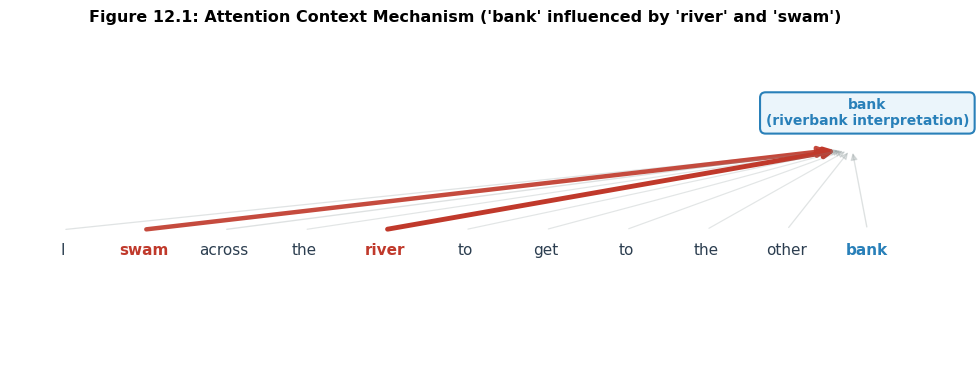

Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/12/result/Figure_12_2.png
Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/Figure_12_2.png


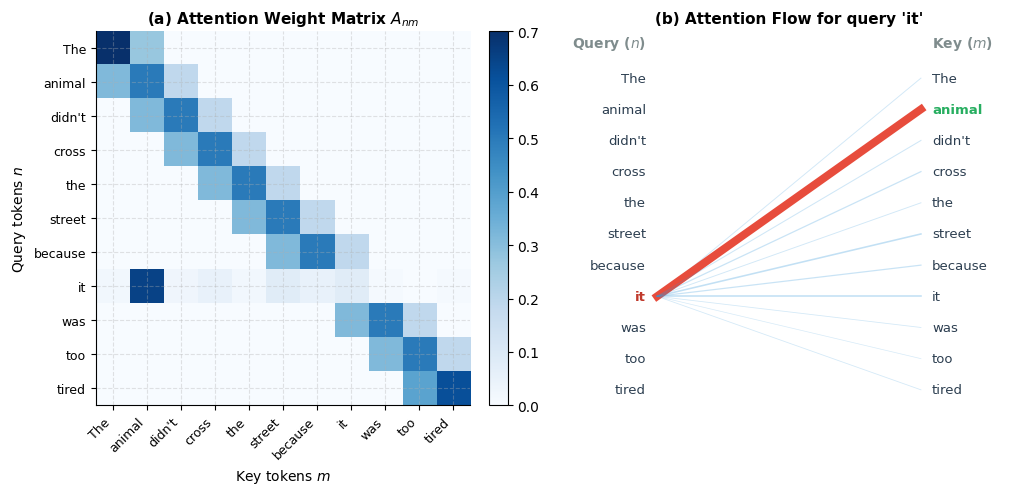

In [2]:
fig_1 = generate_figure_12_1()
plt.show()

fig_2 = generate_figure_12_2()
plt.show()


## 2. トランスフォーマーの処理とデータ行列 (Sections 12.1.1 & 12.1.2)

### 2.1 データ行列 $X$ (Figure 12.3, 式 12.1)
系列長 $N$ 個の各トークン（単語、画像パッチ、アミノ酸等）を $D$ 次元ベクトル $\mathbf{x}_n$ とし、それらを行方向に並べた $N \times D$ 行列 $X$ を入力とします：

$$
X = \begin{pmatrix} \mathbf{x}_1^T \\ \mathbf{x}_2^T \\ \vdots \\ \mathbf{x}_N^T \end{pmatrix} \in \mathbb{R}^{N \times D}
$$

トランスフォーマー層は、入力行列 $X$ を受け取り、同じ次元の表現行列 $\widetilde{X} \in \mathbb{R}^{N \times D}$ を出力する写像です：
$$
\widetilde{X} = \text{TransformerLayer}[X]
$$

### 2.2 注意係数と1の分割 (式 12.2 〜 12.4)
各出力トークン $\mathbf{y}_n$ は、入力トークン群 $\mathbf{x}_1, \dots, \mathbf{x}_N$ の線形結合（ブレンド）として定義されます：
$$
\mathbf{y}_n = \sum_{m=1}^N a_{nm} \mathbf{x}_m
$$
ここで注意係数 $a_{nm}$ は以下の2つの制約（1の分割, partition of unity）を満たします：
$$
a_{nm} \ge 0, \quad \sum_{m=1}^N a_{nm} = 1
$$


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/12/result/Figure_12_3.png
Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/Figure_12_3.png


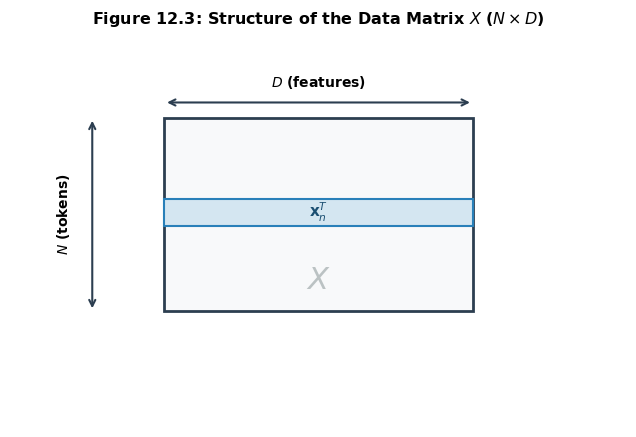

In [3]:
fig_3 = generate_figure_12_3()
plt.show()


## 3. 自己注意機構と情報検索アナロジー (Sections 12.1.3 & 12.1.4)

### 3.1 クエリ・キー・バリューの概念
情報検索（例：動画配信サービス）において：
- **クエリ (Query, $Q$)**: 探したい属性（「コメディ」「アクション」等の検索条件）
- **キー (Key, $K$)**: 各動画カタログに付与された属性インデックス
- **バリュー (Value, $V$)**: 実際に再生される動画ファイル本体

トランスフォーマーではこれを連続空間でのソフト注意（Soft Attention）として一般化し、全微分配信可能なニューラルネット演算とします。

### 3.2 独立パラメータの導入 (Figure 12.4, 12.5)
単純な内積 $X X^T$ や共通重み $X U U^T X^T$ では類似度行列が対称になり、「ノミ（chisel）は工具（tool）であるが、工具は必ずしもノミではない」という現実世界の非対称な関係を表現できません。
そこでクエリ、キー、バリューに独立した学習可能パラメータ行列 $W_Q, W_K, W_V$ を導入します：
$$
Q = X W_Q \in \mathbb{R}^{N \times D_k}, \quad K = X W_K \in \mathbb{R}^{N \times D_k}, \quad V = X W_V \in \mathbb{R}^{N \times D_v}
$$


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/12/result/Figure_12_4.png


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/Figure_12_4.png


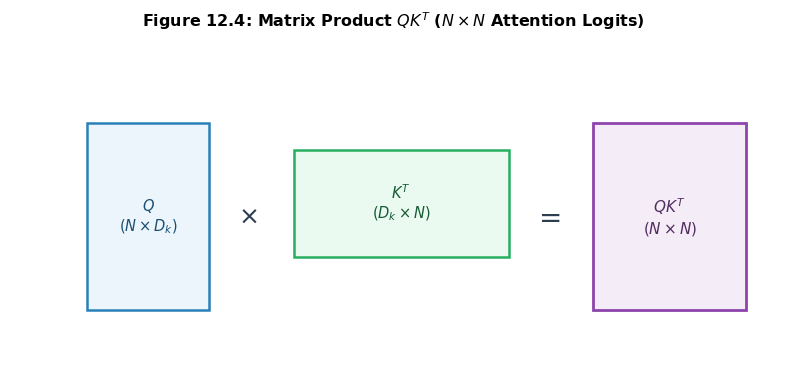

Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/12/result/Figure_12_5.png


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/Figure_12_5.png


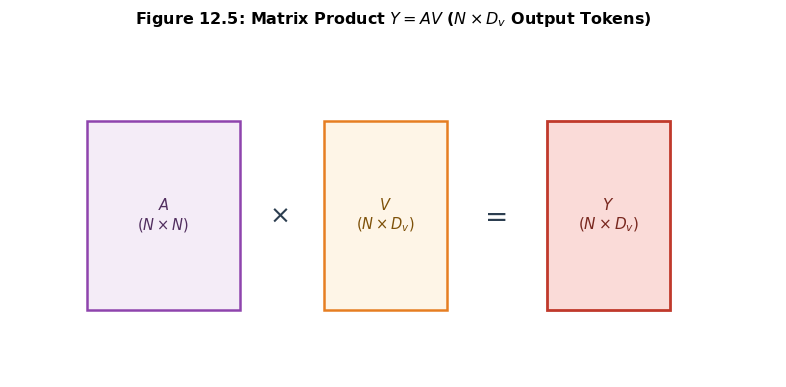

In [4]:
fig_4 = generate_figure_12_4()
plt.show()

fig_5 = generate_figure_12_5()
plt.show()


## 4. スケール化自己注意とマルチヘッド注意 (Sections 12.1.5 & 12.1.6)

### 4.1 スケール化自己注意 (Scaled Dot-Product Self-Attention, Figure 12.6, Algorithm 12.1)
キーの次元 $D_k$ が大きくなると、内積 $\mathbf{q}_n^T \mathbf{k}_m$ の分散が $D_k$ に比例して増大し、ソフトマックス関数の極端な飽和（勾配消失）を引き起こします。
これを防ぐため、$1 / \sqrt{D_k}$ でスケーリングします（式 12.14）：
$$
\text{Attention}(Q, K, V) = \text{Softmax}\left( \frac{Q K^T}{\sqrt{D_k}} \right) V
$$

### 4.2 マルチヘッド注意 (Multi-Head Attention, Figure 12.7, 12.8, Algorithm 12.2)
単一の注意機構脈では1種類の文脈関係しか捉えられません。
入力を $H$ 個の独立したヘッドに射影し、並列に注意を計算したのち連結して線形変換 $W^{(o)}$ で統合します（式 12.15 〜 12.19）：
$$
H_h = \text{Attention}\left( X W_Q^{(h)}, X W_K^{(h)}, X W_V^{(h)} \right) \in \mathbb{R}^{N \times D_v}
$$
$$
Y(X) = \text{Concat}[H_1, H_2, \dots, H_H] W^{(o)} \in \mathbb{R}^{N \times D}
$$
通常 $D_v = D_k = D / H$ と設定され、単一ヘッドと同等の計算量で豊かな多角的関係性を捉えます。


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/12/result/Figure_12_6.png
Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/Figure_12_6.png


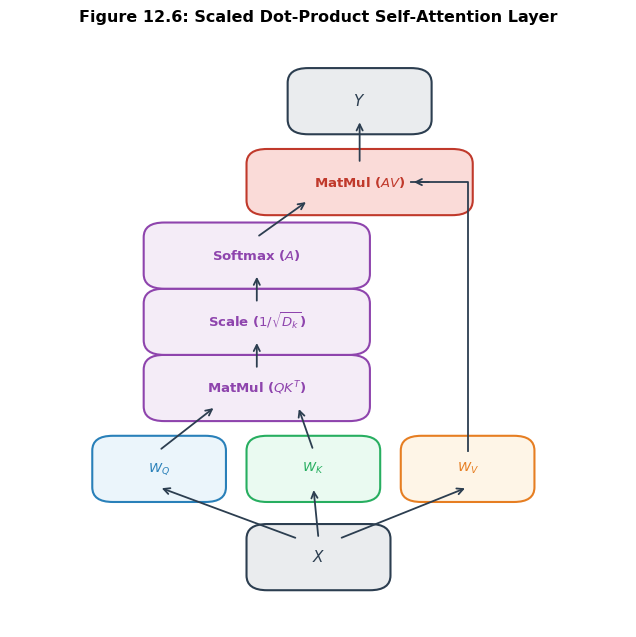

Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/12/result/Figure_12_7.png
Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/Figure_12_7.png


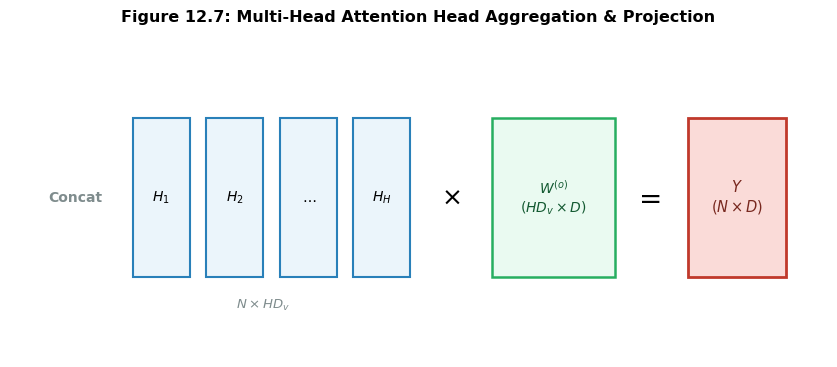

Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/12/result/Figure_12_8.png
Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/Figure_12_8.png


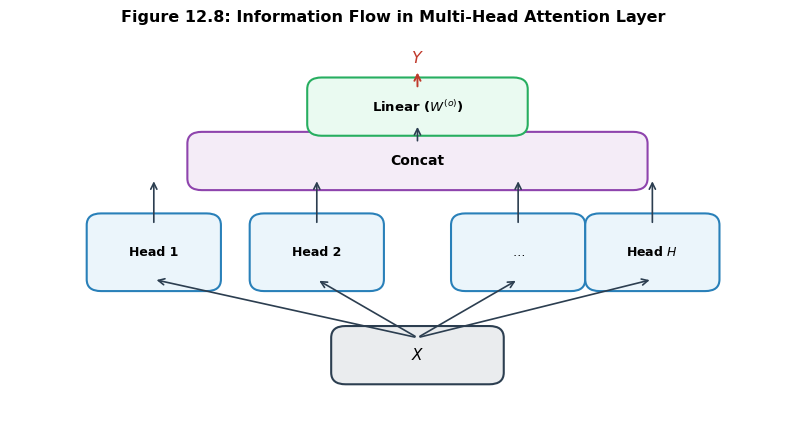

In [5]:
fig_6 = generate_figure_12_6()
plt.show()

fig_7 = generate_figure_12_7()
plt.show()

fig_8 = generate_figure_12_8()
plt.show()


## 5. トランスフォーマー層と計算量 (Sections 12.1.7 & 12.1.8)

### 5.1 完全なトランスフォーマー層の構造 (Figure 12.9, Algorithm 12.3)
注意機構はバリューベクトルの凸結合であるため、出力は入力ベクトルの張る線形部分空間に制約されます。
表現力を飛躍的に向上させるため、各トークン行に独立して作用する非線形多層パーセプトロン（MLP / Feed-Forward Network）を組み合わせます。
さらに深層学習を安定化させるため、残差接続（Residual Connections）と層正規化（Layer Normalization）を導入します（式 12.20, 12.22）：
$$
Z = \text{LayerNorm}[Y(X) + X]
$$
$$
\widetilde{X} = \text{LayerNorm}[\text{MLP}[Z] + Z]
$$

### 5.2 計算量の比較 (Section 12.1.8)
- **自己注意層**: パラメータ数 $O(D^2)$、計算量 $O(N^2 D)$（全トークン対の内積計算）
- **MLP層**: パラメータ数 $O(D^2)$、計算量 $O(N D^2)$
- **全結合ニューラルネット**: パラメータ数 $O(N^2 D^2)$、計算量 $O(N^2 D^2)$

トランスフォーマーは、全結合ネットワークに比べてパラメータ共有により圧倒的に軽量でありながら、系列長 $N$ に対する全ペア直接注意により長距離依存性を $O(1)$ パスで捉えます。


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/12/result/Figure_12_9.png
Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/Figure_12_9.png


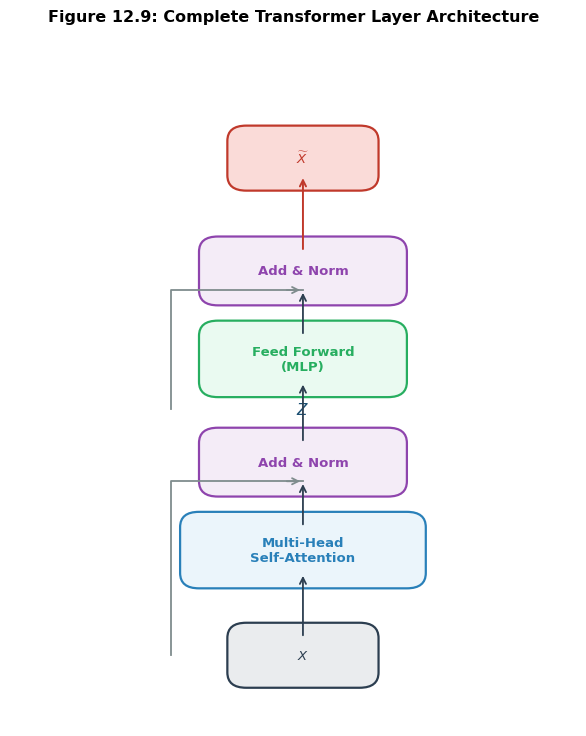

In [6]:
fig_9 = generate_figure_12_9()
plt.show()


## 6. 位置エンコーディング (Section 12.1.9, Figure 12.10)

### 6.1 置換同変性と語順情報の欠落
注意機構とMLPはすべてのトークンでパラメータが共有されているため、入力行を並べ替えると出力行も全く同じ順序で並べ替わる**置換同変性 (Permutation Equivariance)** を持ちます：
「*The food was bad, not good at all.*」と「*The food was good, not bad at all.*」は完全に同一のトークン集合ですが、意味は正反対です。
したがって、モデルに明示的に語順・位置情報を注入する必要があります。

### 6.2 正弦波位置エンコーディング (Vaswani et al., 2017, 式 12.25)
トークンベクトルに同じ次元の位置ベクトル $\mathbf{r}_n$ を加算します（式 12.24）：
$$
\widetilde{\mathbf{x}}_n = \mathbf{x}_n + \mathbf{r}_n
$$
位置 $n$ の各成分 $r_{n, i}$ を異なる波長の正弦波・余弦波で定義します：
$$
r_{n, 2k} = \sin\left( \frac{n}{L^{2k / D}} \right), \quad r_{n, 2k+1} = \cos\left( \frac{n}{L^{2k / D}} \right)
$$
このエンコーディングは以下の優れた性質を持ちます：
1. **有界性**: すべての成分が $[-1, 1]$ に収まり、特徴量を破壊しない。
2. **相対位置の線形表現**: 三角関数の加法定理により、任意の固定相対オフセット $k$ に対して $\mathbf{r}_{n+k}$ は $\mathbf{r}_n$ の線形回転変換として表現可能（$M_k \mathbf{r}_n$）。


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/12/result/Figure_12_10.png


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/Figure_12_10.png


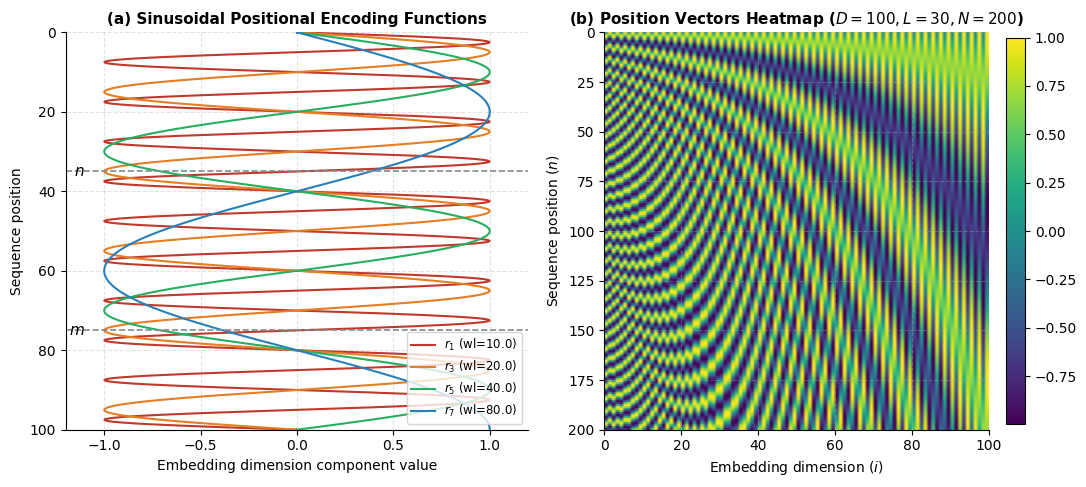

In [7]:
fig_10 = generate_figure_12_10()
plt.show()


## 7. 数値シミュレーションとアルゴリズム検証

実装した自己注意層、マルチヘッド注意、トランスフォーマー層、および正弦波位置エンコーディングの動作をテストします。


In [8]:
# 1. スケール化自己注意の実行と因果マスク (Causal Mask) の確認
d_k, d_v = 8, 8
N = 4
rng = np.random.default_rng(42)
Q = rng.normal(size=(N, d_k))
K = rng.normal(size=(N, d_k))
V = rng.normal(size=(N, d_v))

attn = ScaledDotProductAttention(d_k)
Y_full, A_full = attn.forward(Q, K, V)
print("=== スケール化自己注意 重み行列 A (全結合) ===")
print(np.round(A_full, 3))
print("各行の和:", np.sum(A_full, axis=-1))

# 因果マスク（未来のトークンを隠蔽）
causal_mask = np.triu(np.ones((N, N), dtype=bool), k=1)
Y_causal, A_causal = attn.forward(Q, K, V, mask=causal_mask)
print("\n=== 因果マスク付き自己注意 重み行列 A (下三角) ===")
print(np.round(A_causal, 3))

# 2. 完全なトランスフォーマー層（Post-LN & Pre-LN）の実行
D_model = 16
H_heads = 4
X_tokens = rng.normal(size=(N, D_model))

layer_post = TransformerLayer(d_model=D_model, num_heads=H_heads, pre_norm=False, seed=42)
X_out_post, attn_post = layer_post.forward(X_tokens)

layer_pre = TransformerLayer(d_model=D_model, num_heads=H_heads, pre_norm=True, seed=42)
X_out_pre, attn_pre = layer_pre.forward(X_tokens)

print(f"\nトランスフォーマー層出力形状: {X_out_post.shape} (入力と同形状 N x D を維持)")
print(f"各ヘッドの注意行列数: {attn_post.shape} (H x N x N)")

# 3. 置換同変性と位置エンコーディングの効果
perm = np.array([2, 0, 3, 1])
# 位置エンコーディングなし: 完全な置換同変性
X_perm = X_tokens[perm]
X_out_perm, _ = layer_post.forward(X_perm)
perm_error = np.max(np.abs(X_out_perm - X_out_post[perm]))
print(f"位置情報なしの置換同変性誤差: {perm_error:.2e} (完全同変)")

# 位置エンコーディング加算後: 語順による表現の差別化
R_pe = sinusoidal_positional_encoding(N, D_model)
X_with_pe = layer_post.forward(X_tokens + R_pe)[0]
X_perm_with_pe = layer_post.forward(X_perm + R_pe)[0]
diff_order = np.max(np.abs(X_perm_with_pe - X_with_pe[perm]))
print(f"位置エンコーディング加算による順序感知度: {diff_order:.4f} (> 0: 語順の違いを確実に識別)")


=== スケール化自己注意 重み行列 A (全結合) ===
[[0.294 0.064 0.438 0.203]
 [0.299 0.239 0.335 0.127]
 [0.31  0.256 0.295 0.14 ]
 [0.193 0.44  0.178 0.189]]
各行の和: [1. 1. 1. 1.]

=== 因果マスク付き自己注意 重み行列 A (下三角) ===
[[1.    0.    0.    0.   ]
 [0.556 0.444 0.    0.   ]
 [0.36  0.297 0.343 0.   ]
 [0.193 0.44  0.178 0.189]]

トランスフォーマー層出力形状: (4, 16) (入力と同形状 N x D を維持)
各ヘッドの注意行列数: (4, 4, 4) (H x N x N)
位置情報なしの置換同変性誤差: 0.00e+00 (完全同変)
位置エンコーディング加算による順序感知度: 1.0034 (> 0: 語順の違いを確実に識別)


## 8. まとめと次節 12.2（自然言語処理）への展開

### 本節の要点
1. **注意機構 (Attention)**:
   - 入力データ自身から動的に算出される注意重み $a_{nm}$ により、文脈に応じた柔軟な特徴結合を実現。
2. **スケール化自己注意**:
   - クエリ・キー・バリューの独立射影と $1/\sqrt{D_k}$ スケーリングによる安定した勾配伝播。
3. **マルチヘッド注意**:
   - 複数の表現部分空間を並列探索し、多様な構文・意味関係を同時に抽出。
4. **トランスフォーマー層**:
   - Multi-Head Attention、残差接続、LayerNorm、トークン単位MLPを統合した高効率ブロック。
5. **位置エンコーディング**:
   - 順序不変な注意機構に対し、正弦波・余弦波を加算することで語順情報を完全に保持。

### 次節 12.2 自然言語 (Natural Language) への展開
次節 **12.2 Natural Language** では、生のテキストをトランスフォーマーの入力トークンへと変換する単語埋め込み（Word Embedding, Skip-gram, CBOW）、トークナイゼーション（BPE）、Bag of Words、そして自己回帰言語モデルと再帰型ニューラルネットワーク（RNN）の比較を探究します。
